# Eksperimen Preprocessing - Dreaddit Stress Detection
**Nama**: squishydal  
**Dataset**: Dreaddit - Stress Analysis in Social Media  
**Task**: Binary Classification (label 0 = tidak stress, label 1 = stress)


## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load raw data
train_df = pd.read_csv('../dreaddit_raw/dreaddit-train.csv')
test_df  = pd.read_csv('../dreaddit_raw/dreaddit-test.csv')

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()


Train shape: (2838, 116)
Test shape : (715, 116)


,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167


In [2]:
print("=== Train Info ===")
train_df.info(verbose=False, show_counts=True)


=== Train Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2838 entries, 0 to 2837
Columns: 116 entries, subreddit to sentiment
dtypes: float64(106), int64(6), str(4)
memory usage: 2.5 MB


## 2. Exploratory Data Analysis (EDA)

### 2.1 Statistik Deskriptif

In [3]:
train_df.describe().T.head(20)


,count,mean,std,min,25%,50%,75%,max
id,2838.0,1.375200e+04,1.734016e+04,4.000000e+00,9.262500e+02,1.891500e+03,2.547375e+04,5.575700e+04
label,2838.0,5.243129e-01,4.994965e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
confidence,2838.0,8.089718e-01,1.770383e-01,4.285714e-01,6.000000e-01,8.000000e-01,1.000000e+00,1.000000e+00
social_timestamp,2838.0,1.518107e+09,1.552209e+07,1.483274e+09,1.509698e+09,1.517066e+09,1.530898e+09,1.542592e+09
social_karma,2838.0,1.826216e+01,7.941917e+01,0.000000e+00,2.000000e+00,5.000000e+00,1.000000e+01,1.435000e+03
syntax_ari,2838.0,4.684272e+00,3.316435e+00,-6.620000e+00,2.464243e+00,4.321886e+00,6.505657e+00,2.407423e+01
lex_liwc_WC,2838.0,8.599612e+01,3.233489e+01,5.000000e+00,6.500000e+01,8.100000e+01,1.010000e+02,3.100000e+02
lex_liwc_Analytic,2838.0,3.524094e+01,2.648619e+01,1.000000e+00,1.241000e+01,2.942000e+01,5.505750e+01,9.900000e+01
lex_liwc_Clout,2838.0,4.094823e+01,3.158712e+01,1.000000e+00,1.213500e+01,3.352000e+01,6.932000e+01,9.900000e+01
lex_liwc_Authentic,2838.0,6.704425e+01,3.288064e+01,1.000000e+00,4.107000e+01,8.071000e+01,9.618000e+01,9.900000e+01


### 2.2 Missing Values

In [4]:
missing = train_df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("Tidak ada missing values pada dataset train.")
else:
    print(missing)


Tidak ada missing values pada dataset train.


### 2.3 Distribusi Label (Target)

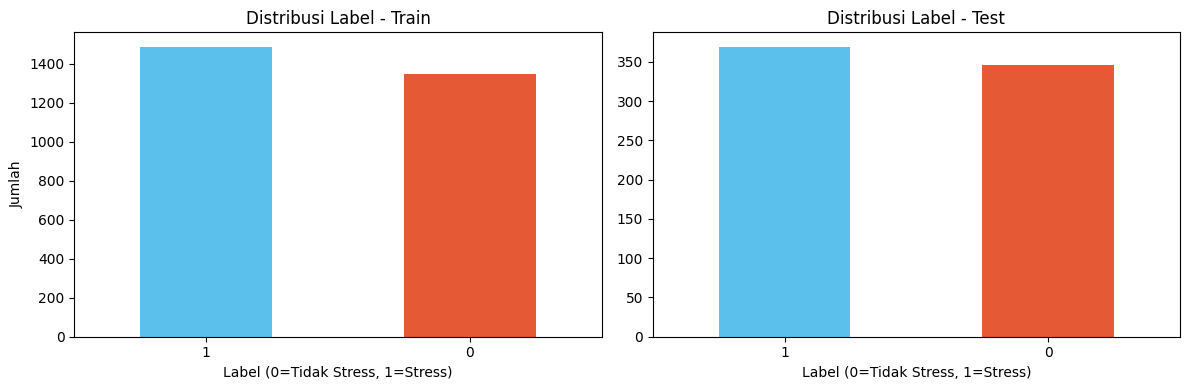

Train label counts:
label
1    1488
0    1350
Name: count, dtype: int64

Test label counts:
label
1    369
0    346
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#5bc0eb','#e55934'])
axes[0].set_title('Distribusi Label - Train')
axes[0].set_xlabel('Label (0=Tidak Stress, 1=Stress)')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Test
test_df['label'].value_counts().plot(kind='bar', ax=axes[1], color=['#5bc0eb','#e55934'])
axes[1].set_title('Distribusi Label - Test')
axes[1].set_xlabel('Label (0=Tidak Stress, 1=Stress)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=100, bbox_inches='tight')
plt.show()

print("Train label counts:")
print(train_df['label'].value_counts())
print("\nTest label counts:")
print(test_df['label'].value_counts())


### 2.4 Distribusi per Subreddit

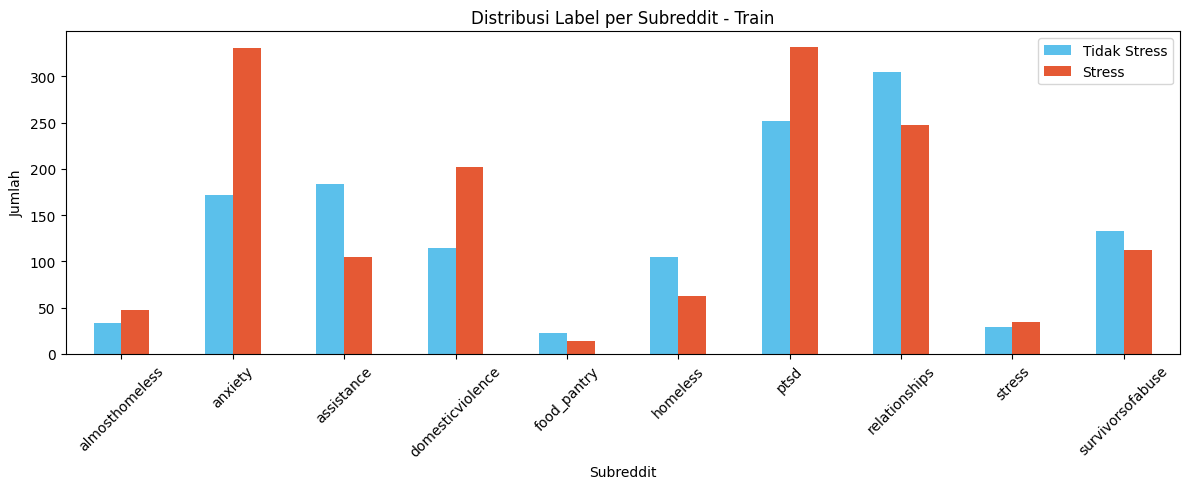

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
subreddit_label = train_df.groupby(['subreddit', 'label']).size().unstack(fill_value=0)
subreddit_label.plot(kind='bar', ax=ax, color=['#5bc0eb','#e55934'])
ax.set_title('Distribusi Label per Subreddit - Train')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Jumlah')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Tidak Stress', 'Stress'])
plt.tight_layout()
plt.savefig('distribusi_subreddit.png', dpi=100, bbox_inches='tight')
plt.show()


### 2.5 Korelasi Fitur Numerik terhadap Label

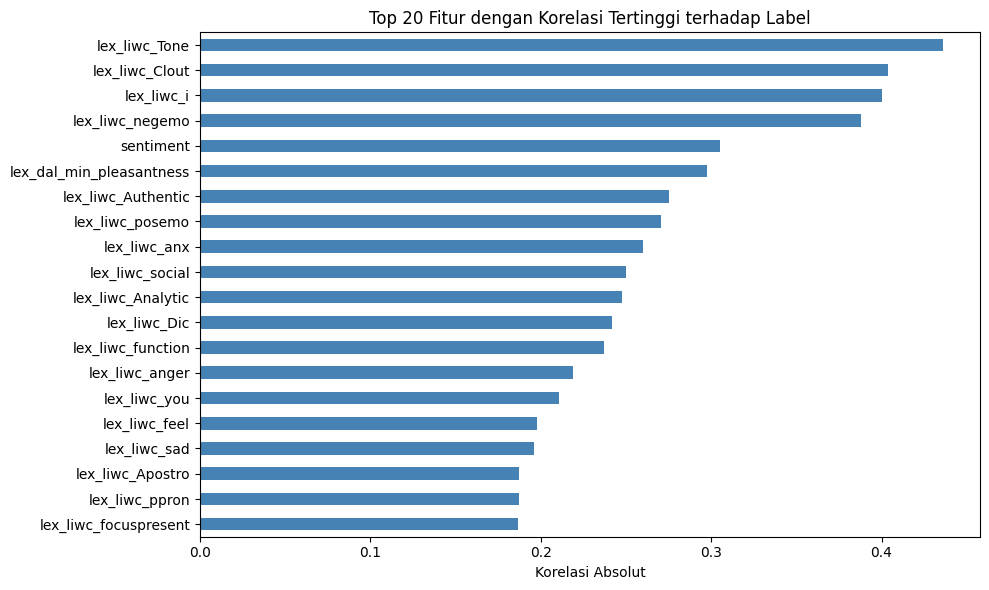

Top 10 fitur paling berkorelasi dengan label:
lex_liwc_Tone               0.436005
lex_liwc_Clout              0.403804
lex_liwc_i                  0.400440
lex_liwc_negemo             0.387979
sentiment                   0.305157
lex_dal_min_pleasantness    0.297439
lex_liwc_Authentic          0.275282
lex_liwc_posemo             0.270672
lex_liwc_anx                0.260146
lex_liwc_social             0.250052
Name: label, dtype: float64


In [7]:
# Kolom yang bukan fitur model
drop_cols = ['id', 'post_id', 'sentence_range', 'text', 'subreddit', 'label', 'confidence']
num_cols = [c for c in train_df.columns if c not in drop_cols]

corr = train_df[num_cols + ['label']].corr()['label'].drop('label').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Fitur dengan Korelasi Tertinggi terhadap Label')
plt.xlabel('Korelasi Absolut')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('korelasi_fitur.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top 10 fitur paling berkorelasi dengan label:")
print(corr.head(10))


### 2.6 Distribusi Beberapa Fitur Penting

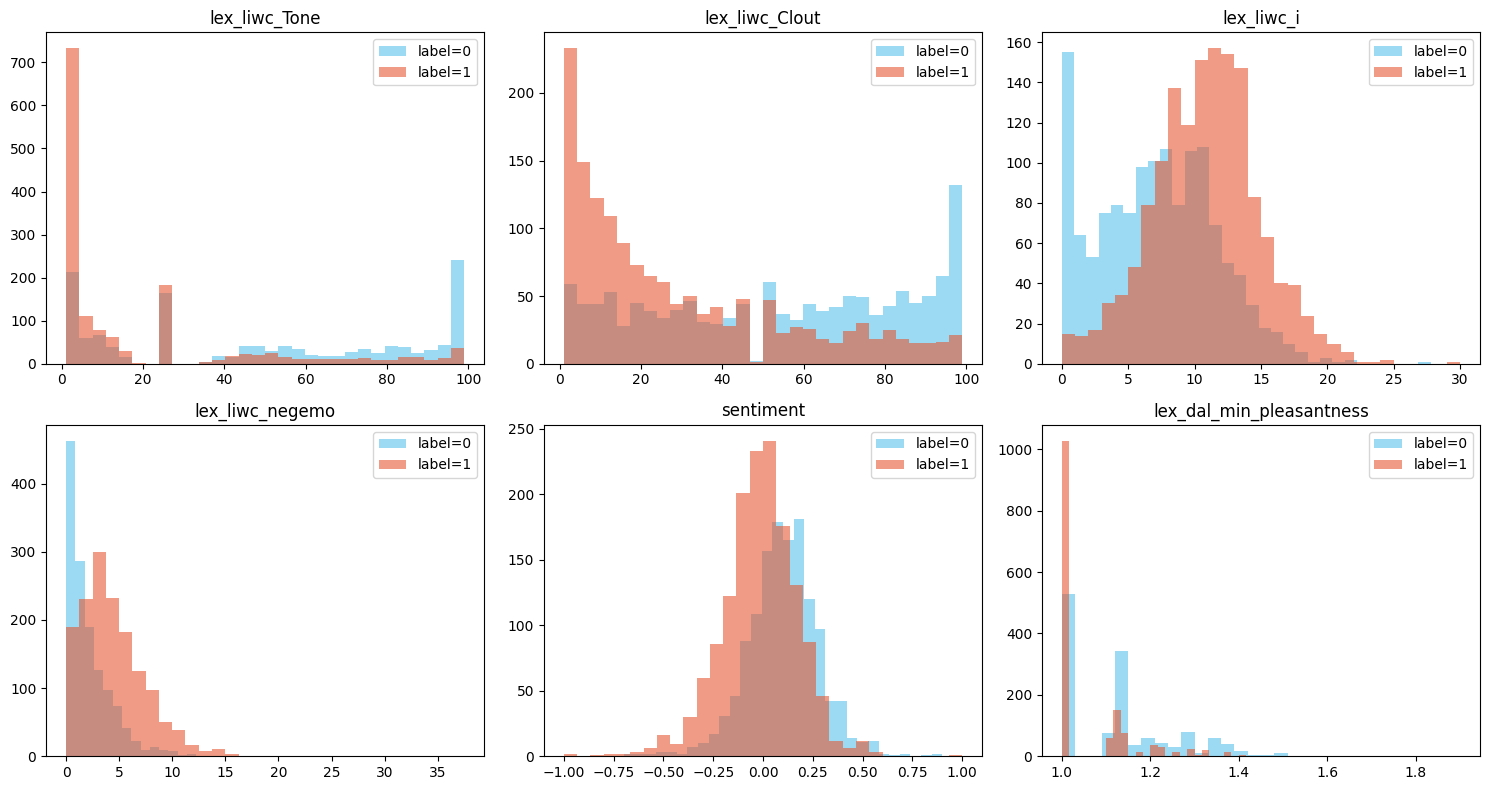

In [8]:
top_features = corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label_val, color in [(0, '#5bc0eb'), (1, '#e55934')]:
        subset = train_df[train_df['label'] == label_val][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label=f'label={label_val}')
    axes[i].set_title(feat)
    axes[i].legend()

plt.tight_layout()
plt.savefig('distribusi_fitur_penting.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Preprocessing

### 3.1 Drop Kolom yang Tidak Digunakan

In [9]:
# Kolom identifier dan teks mentah tidak digunakan untuk model klasik
drop_cols = ['id', 'post_id', 'sentence_range', 'text', 'confidence']

train_clean = train_df.drop(columns=drop_cols)
test_clean  = test_df.drop(columns=drop_cols)

print("Train shape setelah drop:", train_clean.shape)
print("Test shape setelah drop :", test_clean.shape)


Train shape setelah drop: (2838, 111)
Test shape setelah drop : (715, 111)


### 3.2 Encode Kolom Kategorikal (subreddit)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_clean['subreddit'] = le.fit_transform(train_clean['subreddit'])
test_clean['subreddit']  = le.transform(test_clean['subreddit'])

print("Subreddit encoding mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")


Subreddit encoding mapping:
  almosthomeless -> 0
  anxiety -> 1
  assistance -> 2
  domesticviolence -> 3
  food_pantry -> 4
  homeless -> 5
  ptsd -> 6
  relationships -> 7
  stress -> 8
  survivorsofabuse -> 9


### 3.3 Pisahkan Fitur dan Target

In [11]:
X_train = train_clean.drop(columns=['label'])
y_train = train_clean['label']

X_test  = test_clean.drop(columns=['label'])
y_test  = test_clean['label']

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribusi:", y_train.value_counts().to_dict())
print("y_test  distribusi:", y_test.value_counts().to_dict())


X_train: (2838, 110)
X_test : (715, 110)
y_train distribusi: {1: 1488, 0: 1350}
y_test  distribusi: {1: 369, 0: 346}


### 3.4 Feature Scaling (StandardScaler)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Kembalikan ke DataFrame agar lebih mudah dibaca
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Contoh hasil scaling (5 baris pertama, 5 kolom pertama):")
X_train_scaled.iloc[:5, :5]


Contoh hasil scaling (5 baris pertama, 5 kolom pertama):


,subreddit,social_timestamp,social_karma,syntax_ari,lex_liwc_WC
0,0.510734,0.225997,-0.167019,-0.867788,0.928074
1,-0.966049,0.573657,-0.179612,1.431146,0.711551
2,0.510734,1.148796,-0.204800,0.930545,2.505596
3,0.879929,-0.108089,-0.229987,-0.608132,5.784366
4,1.618320,1.398381,0.072260,0.865529,0.092915


### 3.5 Simpan Hasil Preprocessing

In [13]:
import os

output_dir = 'dreaddit_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Gabungkan kembali fitur + label untuk disimpan
train_preprocessed = X_train_scaled.copy()
train_preprocessed['label'] = y_train.values

test_preprocessed = X_test_scaled.copy()
test_preprocessed['label'] = y_test.values

train_preprocessed.to_csv(f'{output_dir}/dreaddit-train-preprocessed.csv', index=False)
test_preprocessed.to_csv(f'{output_dir}/dreaddit-test-preprocessed.csv', index=False)

print("Saved:")
print(f"  {output_dir}/dreaddit-train-preprocessed.csv -> {train_preprocessed.shape}")
print(f"  {output_dir}/dreaddit-test-preprocessed.csv  -> {test_preprocessed.shape}")


Saved:
  dreaddit_preprocessing/dreaddit-train-preprocessed.csv -> (2838, 111)
  dreaddit_preprocessing/dreaddit-test-preprocessed.csv  -> (715, 111)


## 4. Summary Preprocessing

| Tahap | Detail |
|---|---|
| Drop kolom | id, post_id, sentence_range, text, confidence |
| Encode kategorikal | subreddit (LabelEncoder) |
| Feature scaling | StandardScaler pada semua fitur numerik |
| Output train | dreaddit_preprocessing/dreaddit-train-preprocessed.csv |
| Output test | dreaddit_preprocessing/dreaddit-test-preprocessed.csv |
| Jumlah fitur final | 110 fitur + 1 label |
